# 4. Visualization

This section visualizes the main patterns identified in the descriptive statistics. The analysis focuses on geographic distribution, industry composition, education and experience requirements, technical skill demand, and differences in skill requirements across countries and industries.


## 4.1 Import Libraries and Load Data

Replace the GitHub URL below with the Raw URL of `pilot_data_cleaned.xlsx`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../data/cleaned/pilot_data_cleaned.xlsx")

# Convert numerical fields
df["Experience_Min_num"] = pd.to_numeric(df["Experience_Min"], errors="coerce")
df["Experience_Max_num"] = pd.to_numeric(df["Experience_Max"], errors="coerce")
df["Salary_Min_num"] = pd.to_numeric(df["Salary_Min"], errors="coerce")
df["Salary_Max_num"] = pd.to_numeric(df["Salary_Max"], errors="coerce")

df["Salary_Midpoint"] = (df["Salary_Min_num"] + df["Salary_Max_num"]) / 2

print("Dataset shape:", df.shape)


Dataset shape: (100, 30)


## 4.2 Job Postings by Country

This bar chart shows how the job postings are distributed across the countries in the sample.


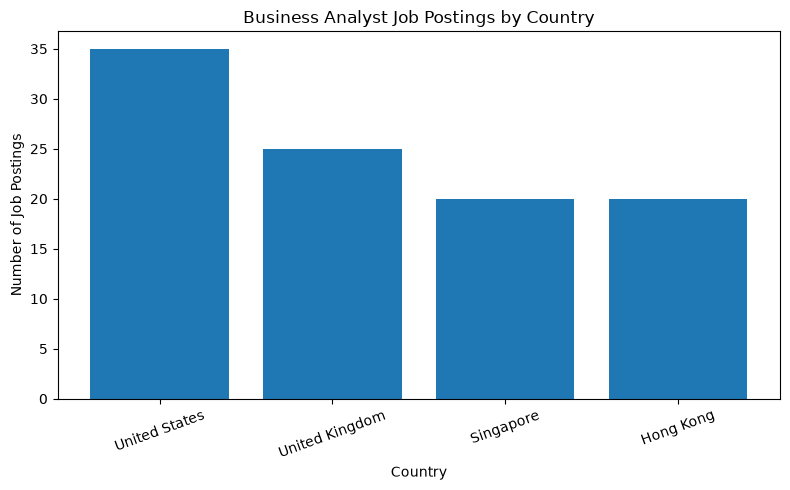

In [3]:
country_counts = df["Country"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(country_counts.index, country_counts.values)
plt.title("Business Analyst Job Postings by Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


This chart shows the distribution of Business Analyst job postings across the countries in the sample. The United States has the most postings (35), followed by the United Kingdom (25), and Singapore and Hong Kong with 20 each. Overall, the sample is heavily skewed toward the U.S. market, followed by the UK, while Singapore and Hong Kong have equal sample sizes. Therefore, cross-country comparisons should be interpreted with caution, especially since differences between the U.S. and other markets may partly reflect unequal sample sizes.



## 4.3 Job Postings by Industry

Industry labels are standardized for visualization so that capitalization differences do not create separate categories.


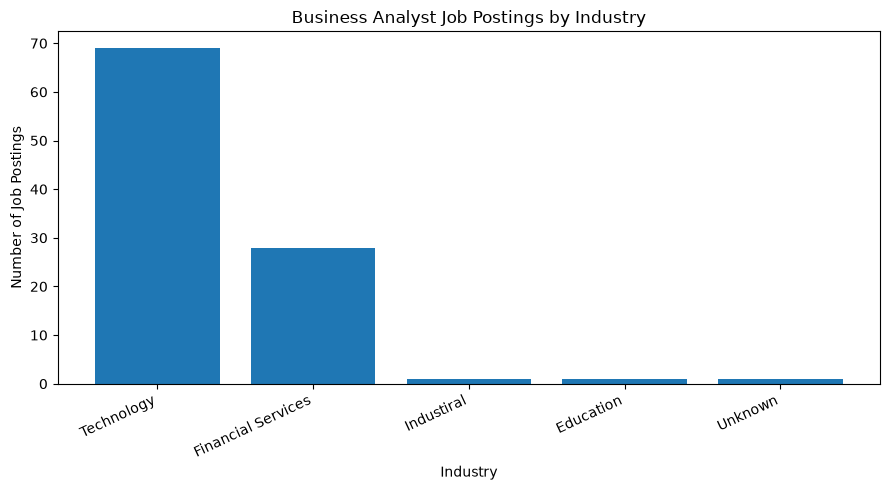

In [4]:
industry_clean = df["Industry"].astype("string").str.strip()

industry_clean = industry_clean.str.replace(r"(?i)^financial services$", "Financial Services", regex=True)
industry_clean = industry_clean.str.replace(r"(?i)^technology$", "Technology", regex=True)

df["Industry_Clean"] = industry_clean
industry_counts = df["Industry_Clean"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(industry_counts.index, industry_counts.values)
plt.title("Business Analyst Job Postings by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


This chart shows the industry composition of the job postings. The Technology industry dominates overwhelmingly with 69 postings, followed by Financial Services with 28 postings. Other industries appear only sporadically, such as Industrial, Education, and Unknown. This indicates that the sample is highly concentrated in technology and financial services, resulting in an unbalanced industry structure. Consequently, conclusions about industry differences mainly reflect the contrast between Technology and Financial Services, and results for other industries should not be overgeneralized.

## 4.4 Education Requirements

This chart summarizes the educational qualifications specified in the job postings.


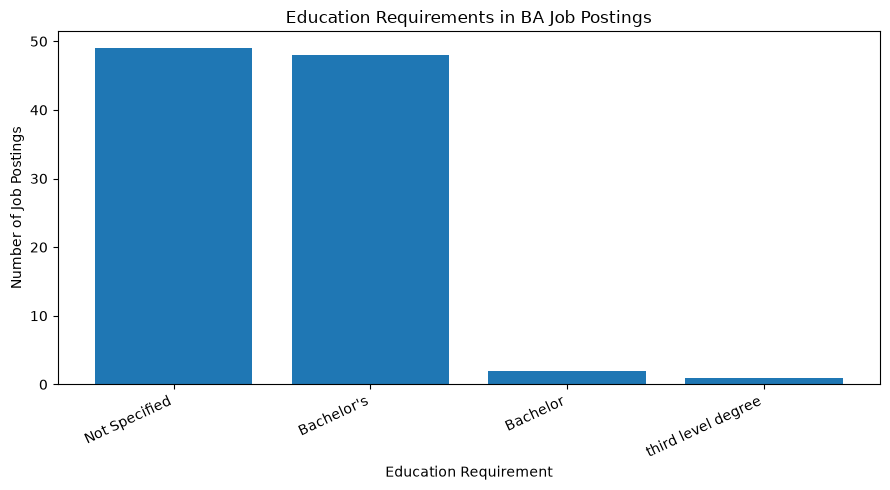

In [5]:
education_counts = df["Education"].fillna("Not Specified").value_counts()

plt.figure(figsize=(9, 5))
plt.bar(education_counts.index, education_counts.values)
plt.title("Education Requirements in BA Job Postings")
plt.xlabel("Education Requirement")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


This chart summarizes the educational qualifications explicitly stated in the job postings. Bachelor’s is the most common requirement, indicating that a bachelor’s degree is typically the basic threshold for Business Analyst roles. At the same time, a considerable number of postings list education as "Not Specified," suggesting that many employers do not explicitly state an education requirement in the job description, or that education is not the sole screening criterion. In addition, a small number of postings use equivalent terms such as "Bachelor" or "third level degree," but overall the bachelor’s degree remains the core requirement.

## 4.5 Distribution of Minimum Required Experience

The histogram shows the distribution of minimum years of experience requested by employers. Non-numeric values are excluded.


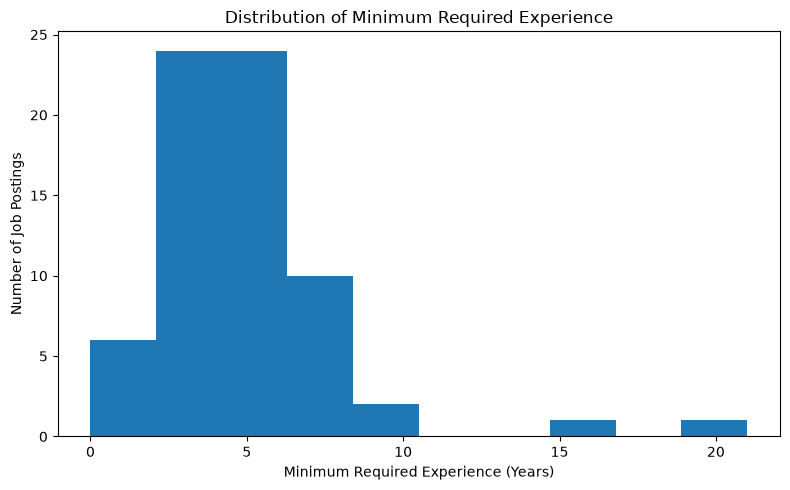

In [6]:
experience_data = df["Experience_Min_num"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(experience_data, bins=10)
plt.title("Distribution of Minimum Required Experience")
plt.xlabel("Minimum Required Experience (Years)")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()


This chart shows the distribution of minimum years of experience requested in the job postings. Among the 68 postings with parseable values, 5 years appears 23 times and 3 years appears 19 times, making them the two most common requirements. Next are 8 years (7 times) and 4 years (5 times). Another 32 postings do not specify a minimum experience requirement. Overall, Business Analyst roles in the sample mainly require 3–5 years of experience, but there are also a few senior positions requiring 8+ years, or even 15 or 21 years, indicating demand across different seniority levels.

## 4.6 Technical Skill Demand

The chart compares the number of job postings that explicitly identify each technical skill.


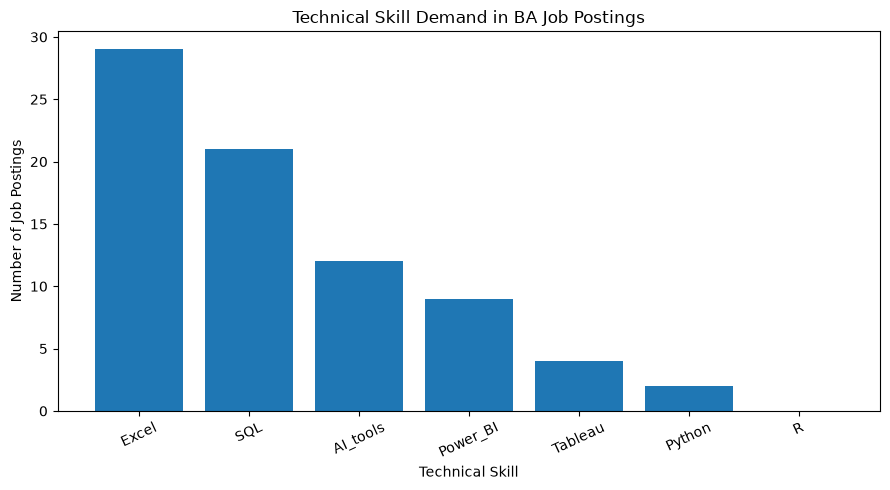

In [7]:
skill_columns = [
    "Excel", "SQL", "Python", "R", "Tableau", "Power_BI", "AI_tools"
]

skill_counts = pd.Series({skill: df[skill].sum() for skill in skill_columns}).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(skill_counts.index, skill_counts.values)
plt.title("Technical Skill Demand in BA Job Postings")
plt.xlabel("Technical Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


This chart compares the frequency of seven technical skills across the 100 job descriptions. Excel appears 29 times and SQL appears 21 times, making them the two most core technical skills. AI_tools appears 12 times, Power_BI 9 times, Tableau 4 times, and Python 2 times; R does not appear at all. The results suggest that Excel and SQL are the most consistently demanded skills for Business Analyst roles, while BI and AI tools have established some demand. Traditional statistical programming languages such as R and Python are not widely required in this sample.

## 4.7 Technical Skill Requirements by Country

The heatmap compares the percentage of job postings mentioning each technical skill within each country. Percentages are used because the number of postings differs across countries.


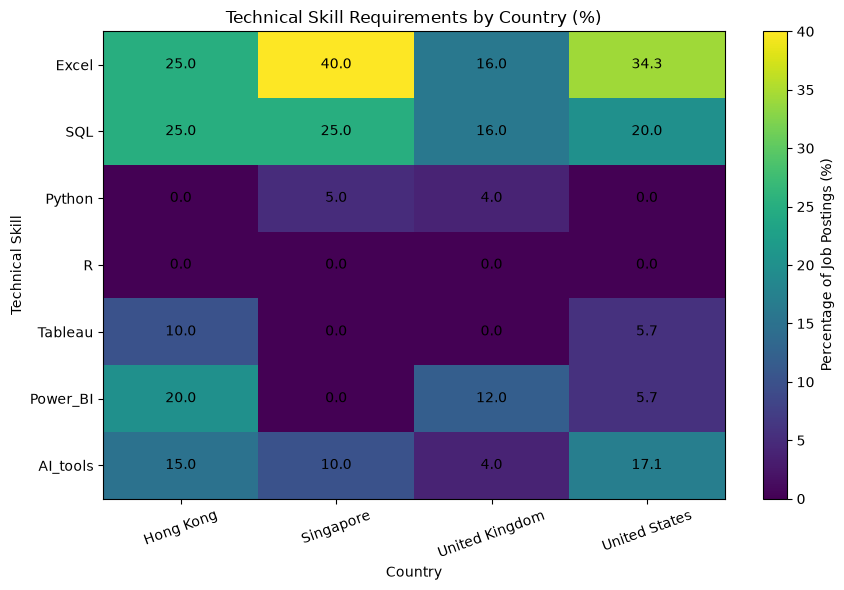

In [8]:
skill_by_country = df.groupby("Country")[skill_columns].mean().mul(100).round(1)
skill_country_matrix = skill_by_country.T

plt.figure(figsize=(9, 6))
plt.imshow(skill_country_matrix, aspect="auto")
plt.title("Technical Skill Requirements by Country (%)")
plt.xlabel("Country")
plt.ylabel("Technical Skill")
plt.xticks(np.arange(len(skill_country_matrix.columns)), skill_country_matrix.columns, rotation=20)
plt.yticks(np.arange(len(skill_country_matrix.index)), skill_country_matrix.index)
plt.colorbar(label="Percentage of Job Postings (%)")

for i in range(skill_country_matrix.shape[0]):
    for j in range(skill_country_matrix.shape[1]):
        plt.text(j, i, f"{skill_country_matrix.iloc[i, j]:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()


This heatmap compares technical skill mention rates by country. Among U.S. postings, Excel is about 34.3%, SQL about 20.0%, and AI_tools about 17.1%. The UK shows relatively lower explicit skill mention rates, with Excel and SQL each at about 16.0% and Power_BI at about 12.0%. Singapore has the highest Excel requirement at about 40.0% and SQL at about 25.0%. Hong Kong shows Excel and SQL each at about 25.0%, Power_BI at about 20.0%, and AI_tools at about 15.0%, indicating relatively higher mention rates for BI and AI tools. Overall, Excel and SQL are core skills across countries, but tool preferences differ by market. Given the small sample size, these differences should be interpreted with caution.

## 4.8 Technical Skill Requirements by Industry

The heatmap compares the percentage of job postings mentioning each technical skill across industries represented in the dataset.


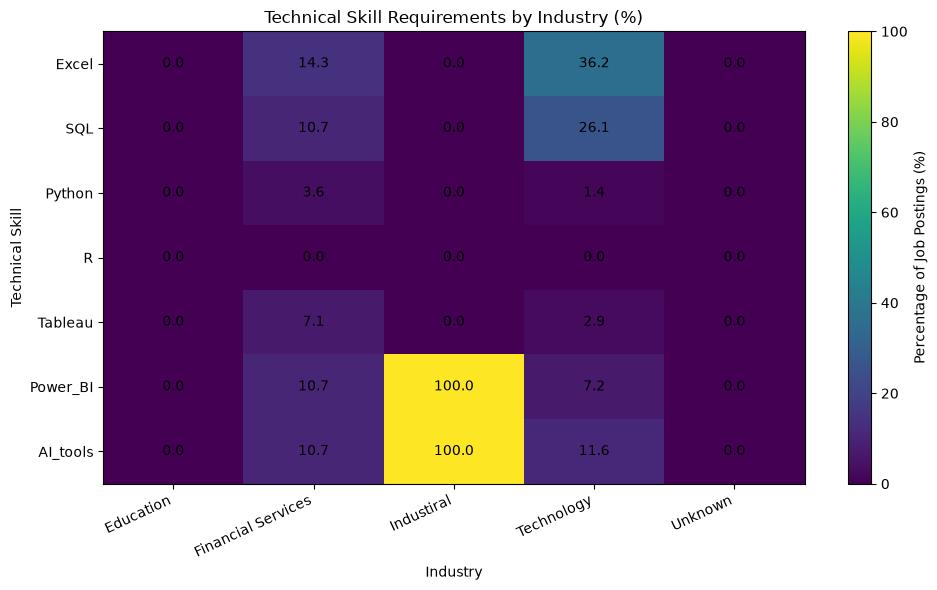

In [9]:
skill_by_industry = df.groupby("Industry_Clean")[skill_columns].mean().mul(100).round(1)
skill_industry_matrix = skill_by_industry.T

plt.figure(figsize=(10, 6))
plt.imshow(skill_industry_matrix, aspect="auto")
plt.title("Technical Skill Requirements by Industry (%)")
plt.xlabel("Industry")
plt.ylabel("Technical Skill")
plt.xticks(np.arange(len(skill_industry_matrix.columns)), skill_industry_matrix.columns, rotation=25, ha="right")
plt.yticks(np.arange(len(skill_industry_matrix.index)), skill_industry_matrix.index)
plt.colorbar(label="Percentage of Job Postings (%)")

for i in range(skill_industry_matrix.shape[0]):
    for j in range(skill_industry_matrix.shape[1]):
        plt.text(j, i, f"{skill_industry_matrix.iloc[i, j]:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()


This heatmap compares technical skill mention rates by industry. In the Technology industry, Excel is mentioned in about 36.2% of postings, SQL about 26.1%, AI_tools about 11.6%, Power_BI about 7.2%, Tableau about 2.9%, and Python about 1.4%. In Financial Services, Excel is about 14.3%, SQL about 10.7%, AI_tools and Power_BI each about 10.7%, Tableau about 7.1%, and Python about 3.6%. It can be seen that Technology places more emphasis on Excel and SQL, while Financial Services shows relatively higher demand for Power BI, Tableau, and AI tools. However, Financial Services has a sample size of 28, and other industries have very few observations, so industry differences should be treated only as descriptive findings within this sample.

## 4.9 Number of Technical Skills per Job Posting

This histogram shows how many of the identified technical skills appear in each job posting.


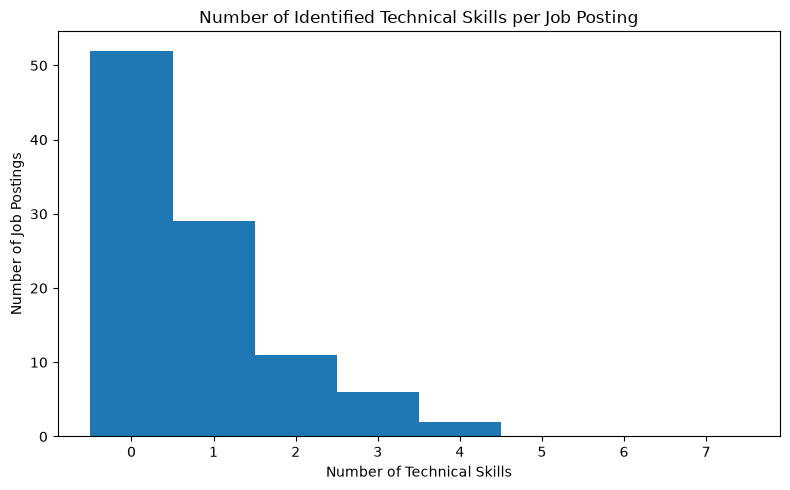

In [10]:
df["Number_of_Skills"] = df[skill_columns].sum(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(df["Number_of_Skills"], bins=np.arange(-0.5, len(skill_columns) + 1.5, 1))
plt.title("Number of Identified Technical Skills per Job Posting")
plt.xlabel("Number of Technical Skills")
plt.ylabel("Number of Job Postings")
plt.xticks(range(len(skill_columns) + 1))
plt.tight_layout()
plt.show()


This chart shows the number of technical skills identified in each job description. Out of 100 postings, 52 have none of the seven technical skills identified, 29 have 1 skill, 11 have 2 skills, 6 have 3 skills, and only 2 have 4 skills. On average, each posting contains about 0.77 technical skills. This suggests that in the sample, most Business Analyst job descriptions do not explicitly list these technical skills, or that the keyword extraction rules are relatively conservative. Among postings that do list technical skills, 1–2 skills are the most common.

## 4.10 Technical Skill Demand by Country

This grouped bar chart provides another view of cross-country differences in technical skill requirements using percentages.


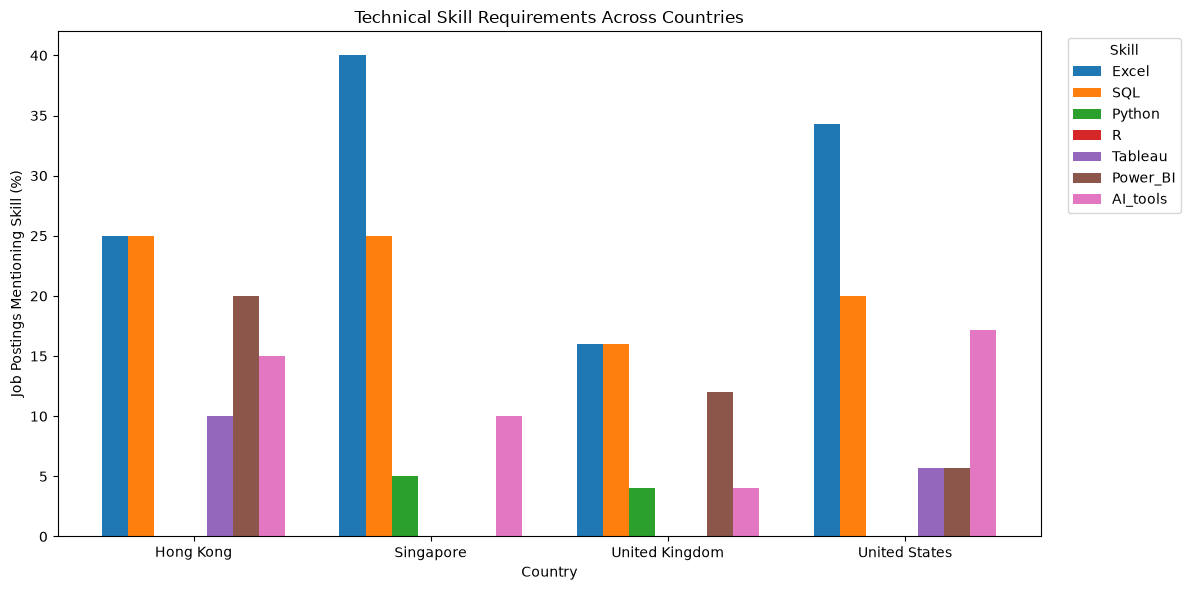

In [11]:
skill_country_pct = df.groupby("Country")[skill_columns].mean().mul(100)

countries = skill_country_pct.index
x = np.arange(len(countries))
width = 0.11

plt.figure(figsize=(12, 6))

for i, skill in enumerate(skill_columns):
    plt.bar(
        x + (i - (len(skill_columns) - 1) / 2) * width,
        skill_country_pct[skill].values,
        width,
        label=skill
    )

plt.title("Technical Skill Requirements Across Countries")
plt.xlabel("Country")
plt.ylabel("Job Postings Mentioning Skill (%)")
plt.xticks(x, countries)
plt.legend(title="Skill", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


This grouped bar chart provides another view of cross-country differences in technical skill requirements. Overall, Excel and SQL are the most important skills in all countries. Singapore has the highest Excel mention rate at about 40.0%. Hong Kong shows relatively stronger emphasis on Power_BI, Tableau, and AI_tools. The U.S. has a relatively high AI_tools mention rate at about 17.1%, while the UK has generally lower skill mention rates. This chart is consistent with the conclusions from the heatmap in 5.7: core skills are shared across markets, but countries differ in their emphasis on BI and AI tools. Due to the limited sample size, these differences should be viewed as descriptive patterns rather than statistical inferences about the broader labor market.

## 5.11 Visualization Summary

The visualizations provide three main perspectives on the sampled BA labor market. First, the geographic and industry charts describe the composition of the sample. Second, the education and experience charts show the qualifications employers specify. Third, the skill charts and heatmaps reveal differences in technical skill requirements across countries and industries. The next section can build on these patterns through text analysis and job-posting segmentation using TF-IDF and K-Means clustering.


## Risk
The sample has several specific limitations. First, it contains only 100 Business Analyst job postings, which limits the statistical power and generalizability of the findings. Second, all observations come from LinkedIn, so the sample may not represent Business Analyst positions advertised through other platforms or offline recruitment channels. Third, the geographic coverage is limited to four markets: the United States (35 postings), the United Kingdom (25), Singapore (20), and Hong Kong (20), meaning the results may not reflect BA labor markets in other countries or regions. Fourth, the sample is highly concentrated in the Technology industry (69 postings) and Financial Services (27 postings), while only a few observations come from other industries, creating potential industry-selection bias. Fifth, the postings were collected over a relatively short period, from September 15 to September 22, 2026, and the job posting dates range from February 24 to September 22, 2026; therefore, the results represent a snapshot of the market rather than long-term hiring trends. Finally, salary information is incomplete: only 33 postings report a salary minimum and 34 report a salary maximum, and the four markets use different currencies (USD, GBP, SGD, and HKD), which limits direct salary comparisons.
